# DreemGO - Exploratory Data Analysis (EDA) & Análisis Predictivo
--- 
Este notebook contiene el análisis de las tres fuentes de datos que alimentan el motor de DreemGO:
1. **Inventario Espacial** (MINCETUR Enriquecido)
2. **Series de Tiempo Climáticas** (Open-Meteo 10 años)
3. **Eventos y Comercios Dinámicos** (Marketplace Turístico)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Análisis Espacial (Catálogo Turístico Estático)

Inventario total   : 6160
Geolocalizables    : 4915  (79.8 %)
Sin coordenadas    : 1245

Jerarquia oficial (dato extraido de la ficha, verificado en DataAnalysis.md 3.1):
JERARQUIA_OFICIAL
1    2577
2    2144
3    1122
4     317


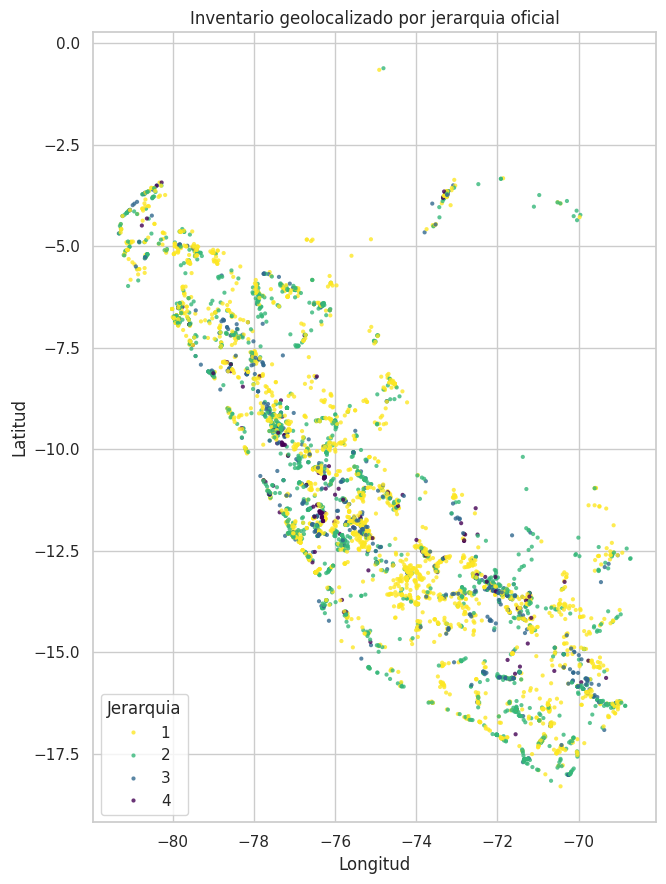

In [2]:
# Data maestra. Se descarta EPOCA_PROPICIA porque no es dato de la ficha oficial:
# clean_impute_dataset.py la sobrescribio con una regla sobre ZONA_CLIMATICA y solo
# tiene 3 valores. Ver DataAnalysis.md seccion 3.1.
df_master = pd.read_csv('../data/processed/dreemgo_master_dataset.csv', sep=';')
df_master = df_master.drop(columns=['EPOCA_PROPICIA'], errors='ignore')

df_master['latitud']  = pd.to_numeric(df_master['latitud'], errors='coerce')
df_master['longitud'] = pd.to_numeric(df_master['longitud'], errors='coerce')
df_mapa = df_master.dropna(subset=['latitud', 'longitud'])

print(f"Inventario total   : {len(df_master)}")
print(f"Geolocalizables    : {len(df_mapa)}  ({len(df_mapa)/len(df_master)*100:.1f} %)")
print(f"Sin coordenadas    : {df_master['latitud'].isna().sum()}")
print()
print('Jerarquia oficial (dato extraido de la ficha, verificado en DataAnalysis.md 3.1):')
print(df_master['JERARQUIA_OFICIAL'].value_counts().sort_index().to_string())

plt.figure(figsize=(7, 9))
sns.scatterplot(data=df_mapa, x='longitud', y='latitud', hue='JERARQUIA_OFICIAL',
                palette='viridis_r', s=9, linewidth=0, alpha=.8)
plt.title('Inventario geolocalizado por jerarquia oficial')
plt.xlabel('Longitud'); plt.ylabel('Latitud')
plt.gca().set_aspect(1.0)
plt.legend(title='Jerarquia', loc='lower left')
plt.tight_layout(); plt.show()


## 2. Analisis climatico (viabilidad historica, no pronostico)

Diez anios de precipitacion mensual (2014-2023, Open-Meteo Archive) para las 24 regiones.
Describe la **norma climatica** de cada region: no predice un mes concreto y no modela
eventos extremos. No hay ninguna fuente de huaicos en este pipeline.

Limitacion: la serie es por region, y una region peruana puede ir del nivel del mar a
6 000 m. El cruce por `REGION x ZONA_CLIMATICA` queda para la semana 7.


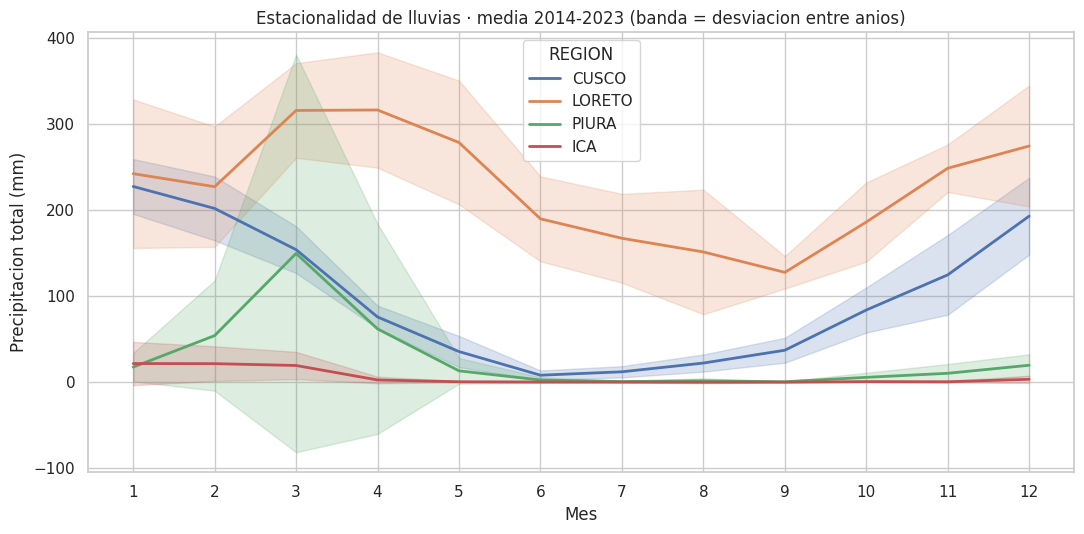

Cusco: enero 228 mm  ->  junio 8 mm   (factor 28x)
Ica  : enero 22 mm  ->  junio 0 mm

Meses-region por nivel de riesgo:
NIVEL_RIESGO_CLIMATICO
1_Seguro        1293
2_Precaucion     618
3_Peligro        969


In [3]:
df_clima = pd.read_csv('../data/processed/historial_clima_regiones.csv', sep=';')
df_clima['MES'] = df_clima['MES'].astype(int)

muestra = ['PIURA', 'CUSCO', 'LORETO', 'ICA']
d = df_clima[df_clima['REGION'].isin(muestra)]

plt.figure(figsize=(11, 5.5))
sns.lineplot(data=d, x='MES', y='PRECIPITACION_TOTAL_MM', hue='REGION', errorbar='sd', lw=2)
plt.title('Estacionalidad de lluvias · media 2014-2023 (banda = desviacion entre anios)')
plt.xticks(range(1, 13)); plt.xlabel('Mes'); plt.ylabel('Precipitacion total (mm)')
plt.tight_layout(); plt.show()

piv = df_clima.groupby(['REGION','MES'])['PRECIPITACION_TOTAL_MM'].mean().unstack()
print('Cusco: enero {:.0f} mm  ->  junio {:.0f} mm   (factor {:.0f}x)'.format(
    piv.loc['CUSCO',1], piv.loc['CUSCO',6], piv.loc['CUSCO',1]/piv.loc['CUSCO',6]))
print('Ica  : enero {:.0f} mm  ->  junio {:.0f} mm'.format(piv.loc['ICA',1], piv.loc['ICA',6]))
print()
print('Meses-region por nivel de riesgo:')
print(df_clima['NIVEL_RIESGO_CLIMATICO'].value_counts().sort_index().to_string())


## 3. Eventos con ventana temporal

> **Aviso:** `comercios_ferias_locales.csv` es un dataset **simulado**, generado por
> `generate_commerce_data.py`. No hay ningun comercio ni feria real aqui. Sirve para
> prototipar el mecanismo de eventos con ventana temporal.
>
> La fuente real prevista son los **749 Acontecimientos Programados** del inventario
> oficial, cuya fecha MINCETUR no publica.


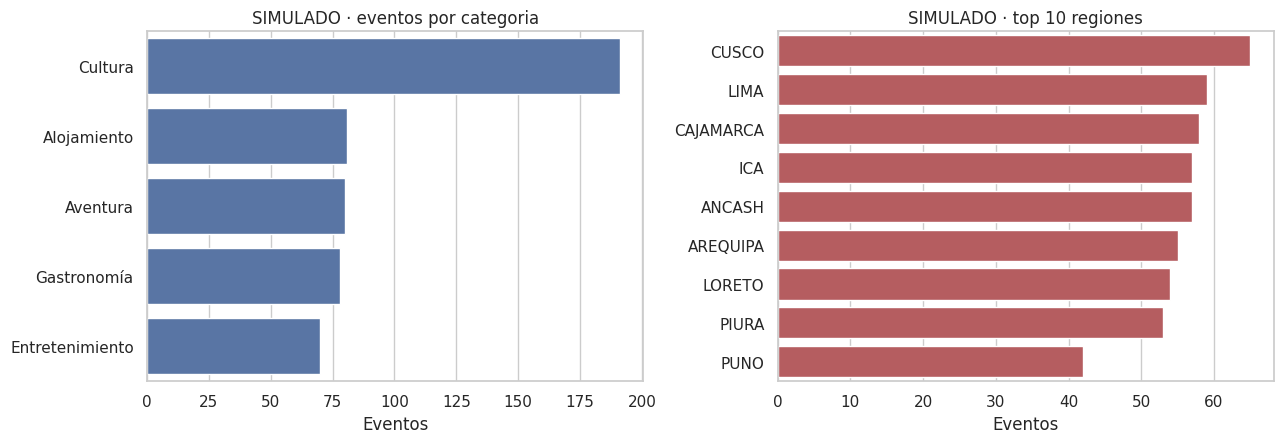

Contraste con el inventario real de MINCETUR:
  Acontecimientos Programados reales : 749  (393 fiestas patronales, 117 festivales,
                                        117 fiestas tradicionales, 23 ferias)
  de ellos SIN coordenada            : 582
  con fecha publicada en el CSV      :   0  <- el vacio que el municipio puede llenar


In [4]:
df_comercio = pd.read_csv('../data/processed/comercios_ferias_locales.csv', sep=';')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
sns.countplot(data=df_comercio, y='CATEGORIA', ax=ax[0],
              order=df_comercio['CATEGORIA'].value_counts().index, color='#4C72B0')
ax[0].set_title('SIMULADO · eventos por categoria'); ax[0].set_xlabel('Eventos'); ax[0].set_ylabel('')

ev = df_comercio['REGION'].value_counts().head(10)
sns.barplot(x=ev.to_numpy(), y=ev.index.to_numpy(), ax=ax[1], color='#C44E52')
ax[1].set_title('SIMULADO · top 10 regiones'); ax[1].set_xlabel('Eventos'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

print('Contraste con el inventario real de MINCETUR:')
print('  Acontecimientos Programados reales : 749  (393 fiestas patronales, 117 festivales,')
print('                                        117 fiestas tradicionales, 23 ferias)')
print('  de ellos SIN coordenada            : 582')
print('  con fecha publicada en el CSV      :   0  <- el vacio que el municipio puede llenar')
